# Mapping and Monitoring Floods

## Introduction

The MODIS Near Real-Time Global Flood Product (Collection 61) (Release 1) (MCDWD) is processed by NASA's Land, Atmosphere Near real-time Capability for EO (LANCE). 

The Flood Product is a daily, near-global, ~250 m resolution product showing flood and surface water detected from the twice-daily overpass of the MODIS optical sensors (onboard Terra and Aqua satellites). To minimize false-positives from cloud and terrain shadows, they employ a multi-observation compositing approach, and generate the product over three compositing periods (1-day, 2-day, and 3-day).  The most optimal composite for a given flood event will depend on: the specific area of interest; cloud cover over dates of interest; potential spatial extent of likely flood water; and likely duration of flooding. Because the 1-day composite can often be contaminated with excess cloud-shadow false-positives, the 2 and 3-day composites are generally preferred, unless latency is critically important, and/or clouds are not a concern on the given date. 

Product generation consists of three key steps: 
1. Water detection algorithm applied to MODIS observations (Terra and Aqua) 

2. Compositing of water detections over 1, 2, and 3 days, to minimize false positives and fill in observations as clouds move. 

3. Differentiating flood from expected surface water (using a reference water mask).

The User Guide for this product can be found [here](https://www.earthdata.nasa.gov/s3fs-public/2024-04/MCDWD_UserGuide_RevD.pdf)

[Source](https://www.earthdata.nasa.gov/learn/find-data/near-real-time/modis-nrt-global-flood-product?)

## Otaining the data
The data can be quickly explored in [Worldview](https://go.nasa.gov/3OiKtYB). 

### Download the data
Data can be downloaded in two file formats, HDF or GeoTIFF. HDF file contains 15 raster layers that include the four flood layer and extra layers that allow users to create costume layers. In this class we are concentrated in the four flood layers:
- 1 Day CS (cloud shadow)
- 1 Day
- 2-Day
- 3-Day

For convenience GeoTIFF layers of the flood layers are offered.

**To download the data**:
1. Enter [here](https://nrt3.modaps.eosdis.nasa.gov/)
3. Go to NRT Data
4. Login or Register for free
5. Go to allData
6. Go to 61, since this is the name of the Collection
7. You can go to [MCDWD_L3_NRT](https://nrt3.modaps.eosdis.nasa.gov/archive/allData/61/MCDWD_L3_NRT) for downloading the HDF file or you can go to [MCDWD_L3_F1_NRT](https://nrt3.modaps.eosdis.nasa.gov/archive/allData/61/MCDWD_L3_F1_NRT), [MCDWD_L3_F2_NRT](https://nrt3.modaps.eosdis.nasa.gov/archive/allData/61/MCDWD_L3_F2_NRT), [MCDWD_L3_F3_NRT](https://nrt3.modaps.eosdis.nasa.gov/archive/allData/61/MCDWD_L3_F3_NRT) to Download the GeoTIFF for 1, 2 or 3 day respectively

**Which file should be downloaded?**

The product is distributed in 10x10° tiles, in a lat/lon (geographic) projection. The tiles are 4800 x 4800 pixels, with pixel size of 0.0020833 degrees (~232 m at the equator). An example product file name for the HDF is MCDWD_L3_NRT.A2021046.h30v12.061.hdf,
indicating date in YYYYDOY (YYYY=year; DOY=day-of-year) format, and tile h-v in MODIS linear latitude/longitude grid

<center><div>
    <img src="./images/modis_tile_map.png" width="700"/>
</div></center>

**What does the information means?**
Each pixel in the raster layer can have the following values:
|Value|Descpription|
|--|--|
|0|No water|
|1|Surface water (matching expected water)|
|2|Recurring flood*|
|3|Flood (unusual)|
|255|Insufficient data|

*Value 2 (Recurring flood) is not yet populated as of Release 1.
[Source](https://www.earthdata.nasa.gov/s3fs-public/2024-04/MCDWD_UserGuide_RevD.pdf)

## Example - Flood in Lybia
The following example shows how to obtain the data for the flood in Lybia for the 11th of September of 2023 and calculate the number of people whose homes were affected by this situation. You can read about the flood [here](https://www.bbc.com/news/world-africa-66961312)
1. Search for the tile where Lybia is located in the tile map. In this case there are seven tiles h18v05, h19v05, h20v05, h18v06, h19v06, h20v06 and h20v07.
2. Calculate how many days of the year there are till September the 11th. In this case 253 days.
3. Decide the flood layer to use, this example uses 2-day layer. In this case, we will use the 12th day of September because the 2-day layer is created using the current day information plus the day before. 
4. Assemble the file name: MCDWD_L3_F2_NRT.A2024254.h19v05.061.tiff
5. Download the file

In [42]:
import rasterio
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [26]:
h12v12 = rasterio.open('../data/MCDWD_L3_F2_NRT.A2024127.h12v12.061.tif')
h12v11 = rasterio.open('../data/MCDWD_L3_F2_NRT.A2024127.h12v11.061.tif')

In [27]:
h12v12.width, h12v12.height

(4800, 4800)

In [28]:
data_h12v12 = h12v12.read(1)
data_h12v11 = h12v11.read(1)

In [29]:
new_data = np.concatenate((data_h12v11, data_h12v12))

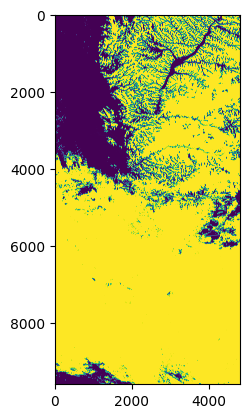

In [38]:
plt.imshow(new_data)
plt.show()

In [45]:
colors = ['white', 'blue', 'yellow', 'red', 'green']
cmap = matplotlib.colors.ListedColormap(colors)

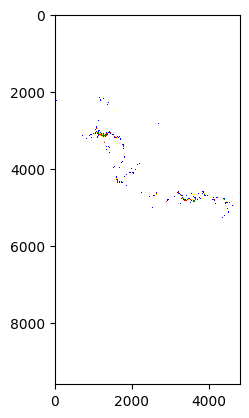

In [46]:
plt.imshow(new_data==3, cmap = cmap)
plt.show()

In [47]:
import folium

In [59]:
h12v12.bounds

BoundingBox(left=-60.0, bottom=-40.0, right=-50.0, top=-30.0)

/tmp/ipykernel_13189/854723083.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = cm.get_cmap('Blues', 10)



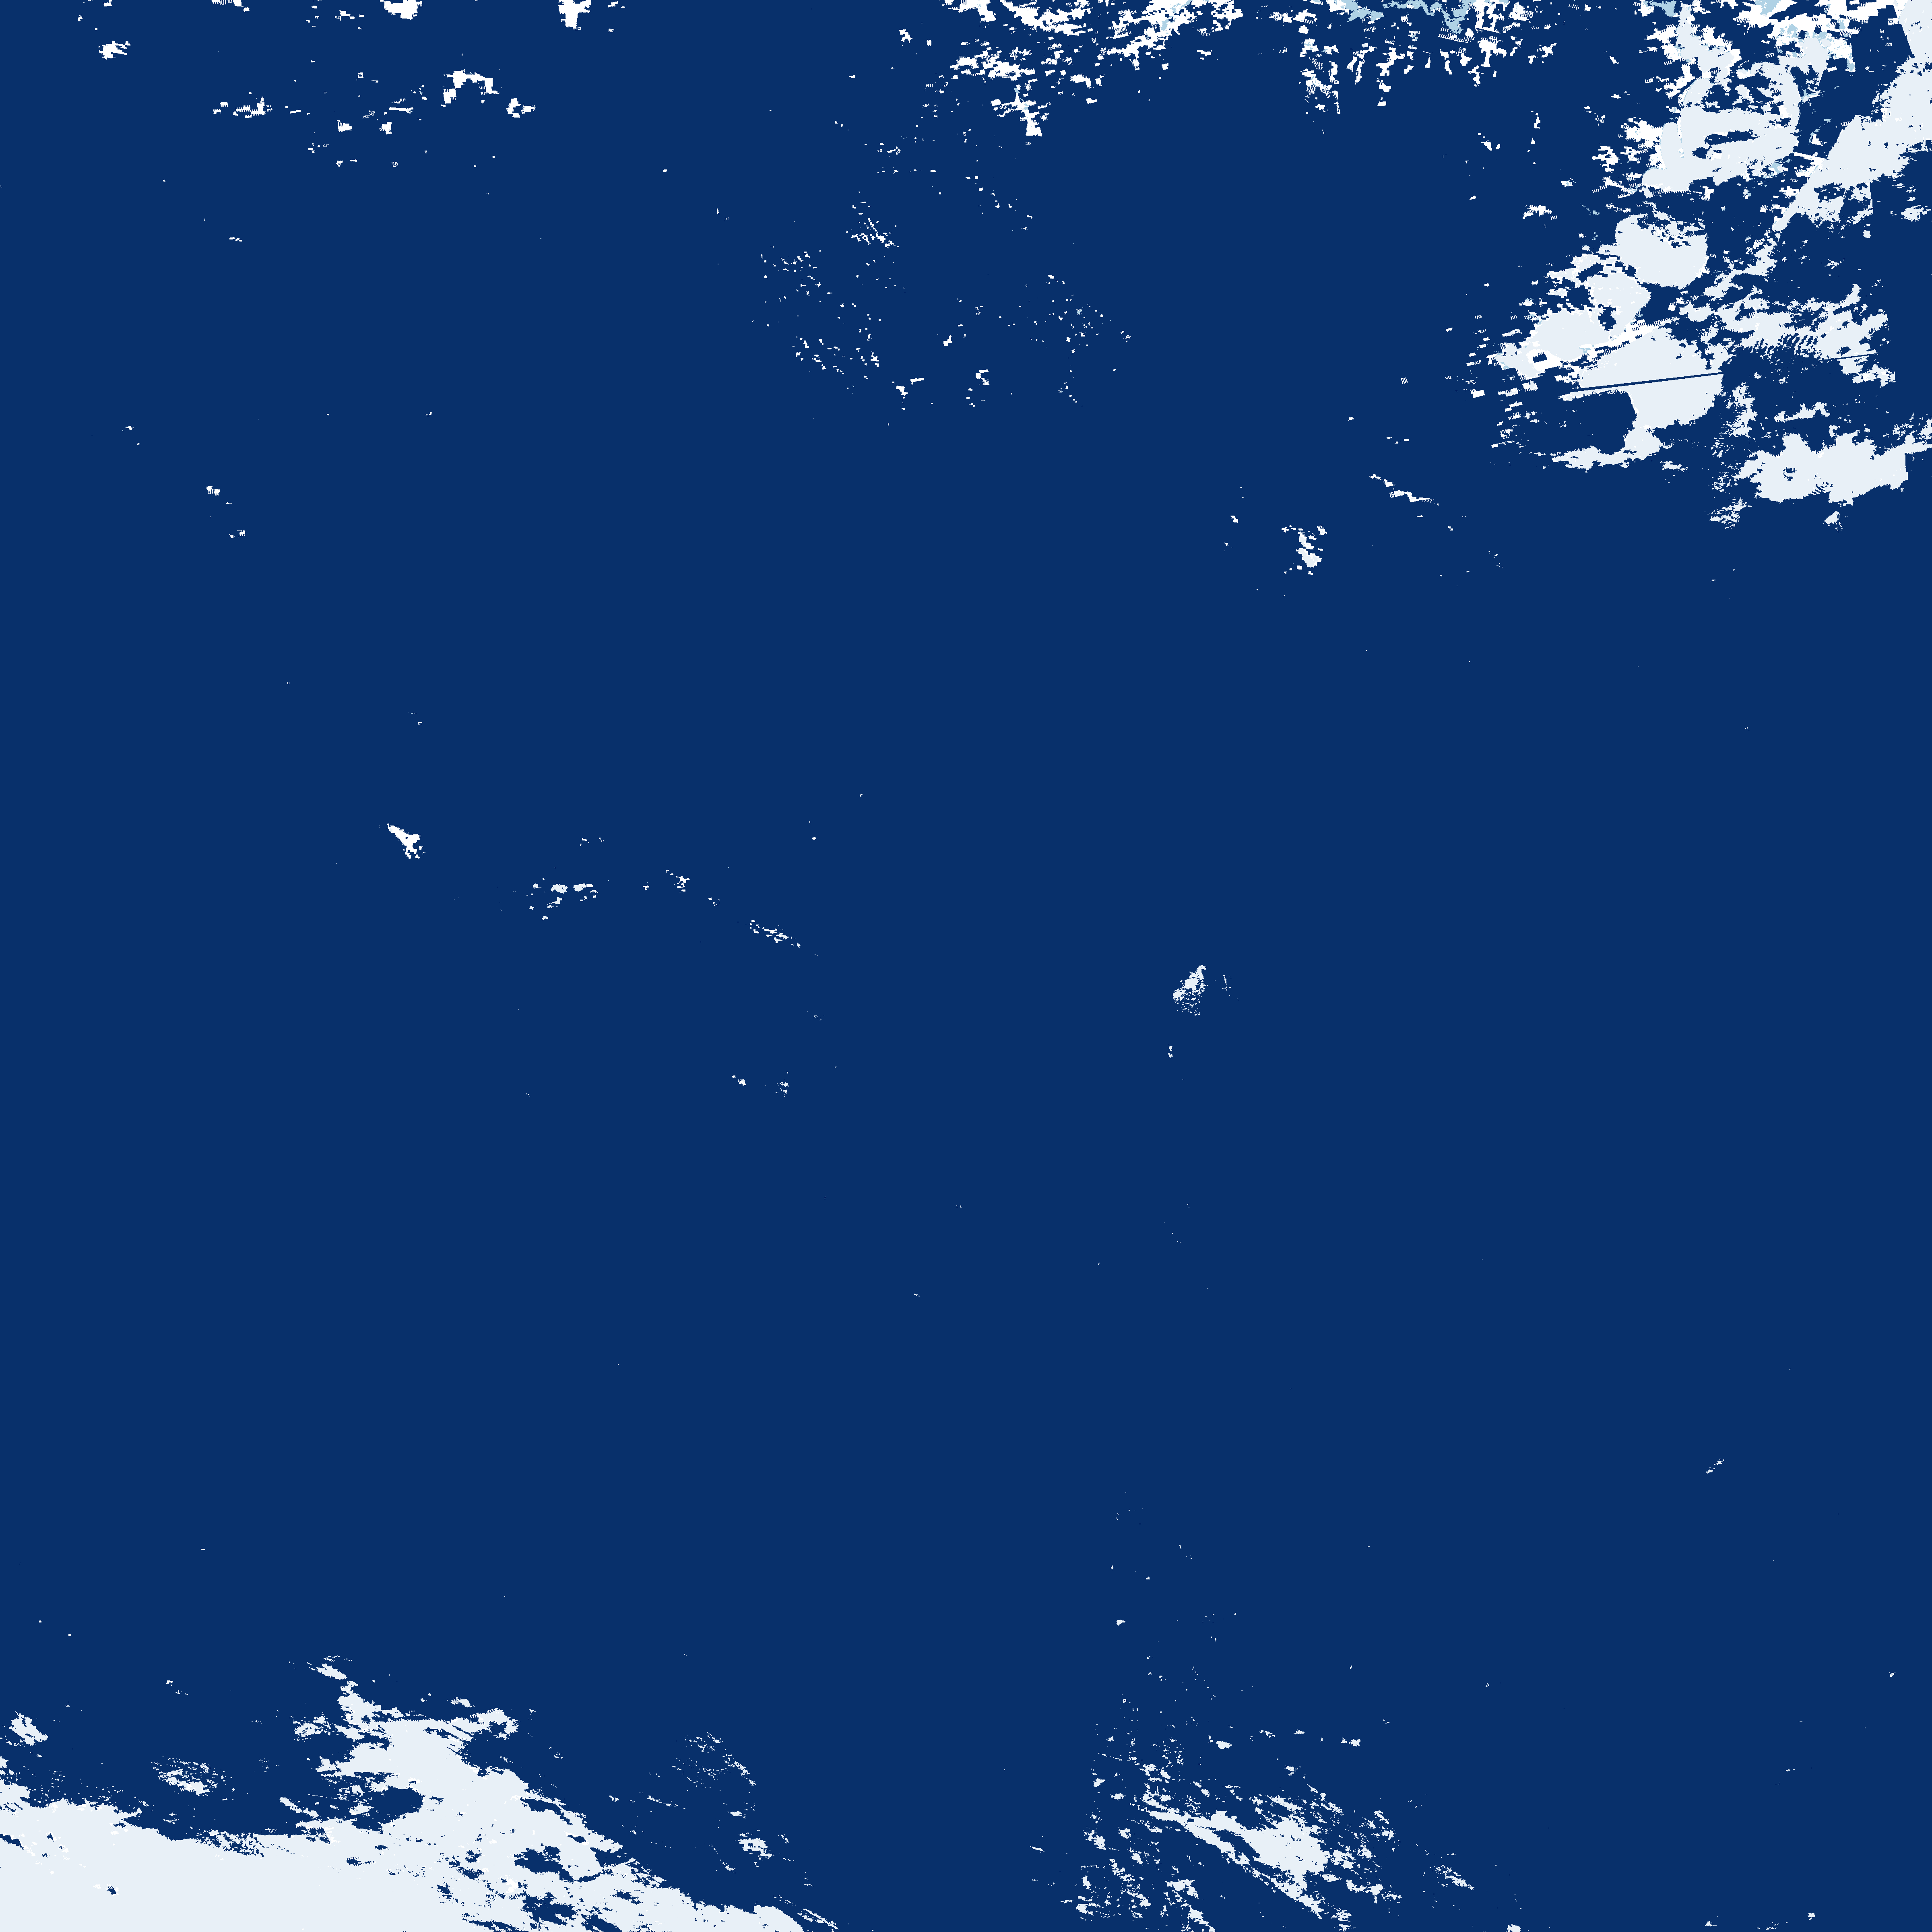

In [66]:
from matplotlib import cm
#define Porto Alegre as the center of the map
map_center = [-30.019817, -51.204118]
m = folium.Map(location=map_center, zoom_start = 9)
image = folium.raster_layers.ImageOverlay(
    image = data_h12v12, 
    bounds = [[-40, -60], [-30, -50]],
    opacity = 0.8,
    interactive = True,
    cross_origin = False, 
    colormap = cm.get_cmap('Blues', 10)
)
image.add_to(m)
folium.LayerControl().add_to(m)
m

### Example - Access the data using the API

### Practice
Now it is your turn!!!
Using the example shown above create a code that calculates the daily number of people affected in Libia flood. 


Some considerations:
- Once a person is affected by the flood, it remains counted as `affected` eventhough there is no more water where they live

article to share: 

Downloading tiles in geotiff seems to be available only during the past week. I explored other options but cannot find it 
- tried with world view and there was no match for september 12th 2023
- 